TypeError: Don't know a PDF representation for <class 'sage.rings.real_mpfr.RealLiteral'> objects

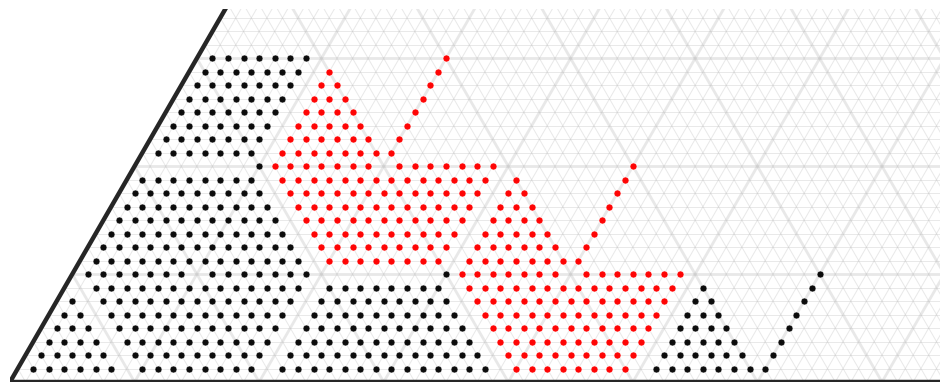

In [1]:
# sl3_hex_boundary_simplex_fill_excl_rightmost.py
# r = 3. Color (in red) every point of any (μ,Λ)-simplex that intersects
# the union of hexagons attached to OUTER-BOUNDARY μ=(3) anchors (ae,be).
#
# Hexagon vertices in ω-coordinates (your latest spec):
#   (ae,be),
#   (ae,(b-2)e+1),
#   ((a+1)e-1,(b-2)e+1),
#   ((a+1)e-1,(b-1)e),
#   ((a-1)e+1,be-1),
#   ((a-1)e+1,(b-1)e)
#
# Boundary anchors are μ=(3) points (ae,be) with (ae+1,be+1) ∉ W_{3,e,w}.
# EXTRA RULE: Exclude the rightmost anchor ((w+1)e, e) ⇔ (a,b)=(w+1,1).
#
# Output: PNG + PDF; dots are BALLS (filled circles), not crosses.

import math
from collections import defaultdict
from typing import Dict, List, Tuple, Set

import matplotlib.pyplot as plt
from matplotlib.path import Path
import numpy as np

SQRT3   = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

# ---------- r=3 partitions & abacus ----------

def enumerate_partitions(Lmax: int):
    """All partitions (l1 >= l2 >= l3 >= 0) with l1 <= Lmax."""
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)

def beta_numbers(lam: Tuple[int,int,int]) -> List[int]:
    """β-numbers for r=3 with ρ-shift: (l1+2, l2+1, l3)."""
    l1, l2, l3 = lam
    return [l1+2, l2+1, l3]

def abacus_from_lam(lam: Tuple[int,int,int], e: int) -> Dict[int, List[int]]:
    """Return runner→(sorted levels) for the e-abacus."""
    per: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per[r].append(q)
    for r in per:
        per[r].sort()
    return per

def e_weight(lam: Tuple[int,int,int], e: int) -> int:
    """Standard e-weight (total removable e-hooks)."""
    w = 0
    for qs in abacus_from_lam(lam, e).values():
        for j, q in enumerate(qs):
            w += (q - j)
    return w

def multipartition_index(lam: Tuple[int,int,int], e: int):
    """
    μ  = runner multiplicities (lengths per chosen runner),
    Λ  = j-partition index (per chosen runner, parts from (q_j - j) positives).
    """
    per = abacus_from_lam(lam, e)
    runners = sorted(per.keys())
    mu = tuple(len(per[r]) for r in runners)
    multipart = []
    for r in runners:
        qs = per[r]
        diffs = [q - j for j, q in enumerate(qs)]
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))
    return mu, tuple(multipart)

def omega_coords_lambda_plus_rho(lam: Tuple[int,int,int]) -> Tuple[int,int]:
    """ω-coordinates for λ+ρ: (ω1, ω2) = (l1 - l2 + 1, l2 - l3 + 1)."""
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)

def safe_Lmax(e: int, w: int) -> int:
    """A safe enumeration cap for (e,w)."""
    return e * (w + 3)

# ---------- Build simplices ----------

def build_simplices(e: int, w: int):
    """
    Return:
      simplices[(μ,Λ)] = set of ω-points in that simplex
      W                 = union of all ω-points
      mu_buckets[μ]     = union for a fixed μ
    """
    Lmax = safe_Lmax(e, w)
    simplices: Dict[Tuple[Tuple[int,...], Tuple[Tuple[int,...], ...]], Set[Tuple[int,int]]] = defaultdict(set)
    mu_buckets: Dict[Tuple[int,...], Set[Tuple[int,int]]] = defaultdict(set)
    for lam in enumerate_partitions(Lmax):
        if e_weight(lam, e) != w:
            continue
        mu, Λ = multipartition_index(lam, e)
        ω = omega_coords_lambda_plus_rho(lam)
        mu_buckets[mu].add(ω)
        simplices[(mu, Λ)].add(ω)
    W = set().union(*simplices.values()) if simplices else set()
    return simplices, W, mu_buckets

# ---------- Geometry & plotting ----------

def to_equilateral(points_fw: List[Tuple[int,int]]):
    """Axial ω-grid → equilateral (X,Y)."""
    X, Y = [], []
    for w1, w2 in points_fw:
        X.append(w1 + 0.5*w2)
        Y.append(SQRT3_2 * w2)
    return X, Y

def extents_from_points(points_fw: List[Tuple[int,int]]):
    X, Y = to_equilateral(points_fw)
    xmin, xmax = min(X), max(X)
    ymin, ymax = min(Y), max(Y)
    mx = max(1.5, 0.15*(xmax - xmin + 1.0))
    my = max(1.5, 0.15*(ymax - ymin + 1.0))
    return max(0.0, xmin - mx), xmax + mx, max(0.0, ymin - my), ymax + my

def draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e: int,
                          alpha: float = 0.35, lw: float = 0.7, lw_bold: float = 2.0):
    """Triangular ω-grid with bold lines at multiples of e."""
    # ω2 = n (horizontal)
    n2_max = int((2.0/math.sqrt(3.0))*(ymax + 1.0)) + 1
    for n in range(0, n2_max+1):
        y = math.sqrt(3.0)/2.0 * n
        if y < ymin - 1 or y > ymax + 1: continue
        x0 = max(xmin, y / math.sqrt(3.0))
        ax.plot([x0, xmax], [y, y], color="0.75", alpha=alpha,
                linewidth=(lw_bold if (n % e == 0 and n != 0) else lw))
    # ω1 = n (down-right)
    n1_min = max(0, int(xmin) - 2)
    n1_max = int(xmax) + 2
    t_cap  = int((2.0/math.sqrt(3.0))*(ymax + 1.0)) + 1
    for n in range(n1_min, n1_max+1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5*t_cap, math.sqrt(3.0)/2.0*t_cap)
        ax.plot([x0, x1], [y0, y1], color="0.75", alpha=alpha,
                linewidth=(lw_bold if (n % e == 0 and n != 0) else lw))
    # ω1 + ω2 = m (down-left)
    m_min = max(0, int(xmin)) - 2
    m_max = int(xmax + (2.0/math.sqrt(3.0))*(ymax + 1.0)) + 2
    for m in range(m_min, m_max+1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1.0)*2.0/math.sqrt(3.0)), m)
        x1 = m - 0.5*t_cap
        y1 = math.sqrt(3.0)/2.0 * t_cap
        ax.plot([x0, x1], [y0, y1], color="0.75", alpha=alpha,
                linewidth=(lw_bold if (m % e == 0 and m != 0) else lw))

def draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw: float = 3.0):
    """Dominant chamber wedge edges."""
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.15", linewidth=lw)
    x0 = max(xmin, 0.0); x1 = min(xmax, ymax / math.sqrt(3.0))
    ax.plot([x0, x1], [math.sqrt(3.0)*x0, math.sqrt(3.0)*x1], color="0.15", linewidth=lw)

# ---------- Refined hexagons & selection ----------

def polygon_order(verts: List[Tuple[float,float]]) -> List[Tuple[float,float]]:
    """Order polygon vertices by polar angle (for Path)."""
    cx = sum(x for x, _ in verts) / len(verts)
    cy = sum(y for _, y in verts) / len(verts)
    return sorted(verts, key=lambda p: math.atan2(p[1]-cy, p[0]-cx))

def refined_hex_vertices(a: int, b: int, e: int) -> List[Tuple[int,int]]:
    """Your refined hexagon (ω-coordinates) at anchor (a,b)."""
    return polygon_order([
        (a*e,           b*e),
        (a*e,           (b-2)*e + 1),
        ((a+1)*e - 1,   (b-2)*e + 1),
        ((a+1)*e - 1,   (b-1)*e),
        ((a-1)*e + 1,   b*e - 1),
        ((a-1)*e + 1,   (b-1)*e),
    ])

def choose_boundary_anchors_excluding_rightmost(e: int,
                                                mu_buckets: Dict[Tuple[int,...], Set[Tuple[int,int]]],
                                                W: Set[Tuple[int,int]], w: int):
    """
    Anchors = μ=(3) multiples (ae,be) with (ae+1,be+1) ∉ W (outer boundary),
    EXCLUDING the rightmost anchor ((w+1)e, e).
    """
    S3 = mu_buckets.get((3,), set())
    anchors = []
    for (w1, w2) in S3:
        if (w1 % e == 0) and (w2 % e == 0) and ((w1+1, w2+1) not in W):
            a, b = w1//e, w2//e
            if not (a == w + 1 and b == 1):  # exclude ((w+1)e, e)
                anchors.append((a, b))
    return sorted(set(anchors))

def select_simplices_by_hexagons(simplices, anchors, e: int) -> Set[Tuple[int,int]]:
    """
    Return the union of ENTIRE simplices that intersect any hexagon.
    """
    if not anchors:
        return set()
    polys = [Path(refined_hex_vertices(a, b, e), closed=True) for (a,b) in anchors]
    red = set()
    for pts in simplices.values():
        if not pts:
            continue
        arr = np.array(list(pts), dtype=float)
        # If ANY point of the simplex lies in a hexagon, take the WHOLE simplex
        if any(poly.contains_points(arr, radius=1e-9).any() for poly in polys):
            red.update(pts)
    return red

# ---------- Render ----------

def render_hex_simplex_fill_excluding_rightmost(e: int, w: int, out_prefix: str):
    simplices, W, mu_buckets = build_simplices(e, w)
    if not W:
        raise RuntimeError(f"No points for (e,w)=({e},{w})")

    anchors = choose_boundary_anchors_excluding_rightmost(e, mu_buckets, W, w)
    red_points = select_simplices_by_hexagons(simplices, anchors, e)

    xmin, xmax, ymin, ymax = extents_from_points(list(W))
    fig, ax = plt.subplots(figsize=(12, 7))
    draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e)

    # BALLS (filled circles) — sized by w for clarity
    size = int(round(32 - 14 * min(max(w, 0), 10) / 10.0))
    size = max(18, min(32, size))

    blacks = sorted(list(W - red_points))
    reds   = sorted(list(red_points))

    if blacks:
        Xb, Yb = to_equilateral(blacks)
        ax.scatter(Xb, Yb, s=size, marker="o", facecolor="black",
                   edgecolor="white", linewidths=0.4, alpha=0.95, zorder=2)
    if reds:
        Xr, Yr = to_equilateral(reds)
        ax.scatter(Xr, Yr, s=size*1.05, marker="o", facecolor="red",
                   edgecolor="white", linewidths=0.5, alpha=0.98, zorder=3)

    draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.2)
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax); ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

    # Keep the label OUTSIDE the chamber area
    # fig.text(0.015, 0.985, f"(r,e,w)=(3,{e},{w})",
    #          ha="left", va="top", fontsize=14, weight="bold")

    png = f"{out_prefix}.png"
    pdf = f"{out_prefix}.pdf"
    fig.savefig(png, dpi=260, bbox_inches="tight")
    fig.savefig(pdf, dpi=260, bbox_inches="tight")
    return anchors, png, pdf

# --------------------------- Example ---------------------------
if __name__ == "__main__":
    e, w = 8, 5
    anchors, png, pdf = render_hex_simplex_fill_excluding_rightmost(
        e, w, out_prefix=f"sl3_e{e}_w{w}_hex_simplex_fill_excl_rightmost"
    )
    print("anchors:", anchors)
    print("PNG:", png)
    # print("PDF:", pdf)


In [5]:
import math
from collections import defaultdict
from typing import Dict, List, Tuple, Set

import matplotlib.pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

# ==========================================
# 1. CORE COMBINATORICS
# ==========================================

SQRT3   = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

def enumerate_partitions_fixed_weight(Lmax: int, weight: int, e: int):
    """Generates partitions of exactly e-weight `weight`."""
    # Using naive cubic scan for robustness with small w (w <= 15).
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                lam = (l1, l2, l3)
                if e_weight(lam, e) == weight:
                    yield lam

def beta_numbers(lam: Tuple[int,int,int]) -> List[int]:
    l1, l2, l3 = lam
    return [l1+2, l2+1, l3]

def abacus_from_lam(lam: Tuple[int,int,int], e: int) -> Dict[int, List[int]]:
    per: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per[r].append(q)
    for r in per:
        per[r].sort()
    return per

def e_weight(lam: Tuple[int,int,int], e: int) -> int:
    w_val = 0
    for qs in abacus_from_lam(lam, e).values():
        for j, q in enumerate(qs):
            w_val += (q - j)
    return w_val

def omega_coords(lam: Tuple[int,int,int]) -> Tuple[int,int]:
    """Coordinates in the fundamental weight basis (omega1, omega2)."""
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)

def build_W_set(e: int, w: int) -> Set[Tuple[int,int]]:
    """Return the set W_{3,e,w} of all points."""
    Lmax = e * (w + 4)
    W = set()
    for lam in enumerate_partitions_fixed_weight(Lmax, w, e):
        W.add(omega_coords(lam))
    return W

# ==========================================
# 2. AFFINE GEOMETRY LOGIC
# ==========================================

def get_affine_vertices_in_range(e: int, max_coord: int) -> List[Tuple[int,int]]:
    """Return grid of (a*e, b*e) for positive integers a,b."""
    limit = max_coord // e + 3
    av = []
    for a in range(1, limit):
        for b in range(1, limit):
            av.append((a*e, b*e))
    return av

def classify_affine_vertices(
    candidates: List[Tuple[int,int]], 
    W: Set[Tuple[int,int]]
) -> Tuple[List[Tuple[int,int]], List[Tuple[int,int]]]:
    """
    Split candidates into Boundary (Pareto optimal in W) and Interior.
    """
    in_W = [v for v in candidates if v in W]
    boundary_av = []
    
    # Boundary: v in W s.t. NO distinct q in W has q >= v
    for v in in_W:
        (a, b) = v
        is_dominated = False
        for q in in_W:
            if v == q: continue
            (qa, qb) = q
            if qa >= a and qb >= b:
                is_dominated = True
                break
        if not is_dominated:
            boundary_av.append(v)
            
    # Interior: Any u s.t. exists boundary v with u <= v and u != v
    interior_av = []
    for u in candidates:
        (ca, cb) = u
        is_interior = False
        for v in boundary_av:
            (va, vb) = v
            if ca <= va and cb <= vb:
                if ca < va or cb < vb:
                    is_interior = True
                    break
        if is_interior:
            interior_av.append(u)
            
    return boundary_av, interior_av

def get_hexagon_open_points(center: Tuple[int,int], e: int, W: Set[Tuple[int,int]]) -> Set[Tuple[int,int]]:
    """Points of W strictly inside hexagon centered at 'center' radius e."""
    (cx, cy) = center
    pts = set()
    scan_min_x = cx - e + 1
    scan_max_x = cx + e - 1
    scan_min_y = cy - e + 1
    scan_max_y = cy + e - 1
    
    for (x,y) in W:
        if not (scan_min_x <= x <= scan_max_x): continue
        if not (scan_min_y <= y <= scan_max_y): continue
        if abs((x + y) - (cx + cy)) < e:
            pts.add((x,y))
    return pts

# ==========================================
# 3. PLOTTING
# ==========================================

def to_equilateral(x, y):
    return x + 0.5 * y, SQRT3_2 * y

def draw_hex_outline(ax, center, e, color, lw=1.5, linestyle='-'):
    (cx, cy) = center
    verts_omega = [
        (cx + e, cy - e), (cx + e, cy), (cx, cy + e),
        (cx - e, cy + e), (cx - e, cy), (cx, cy - e),
        (cx + e, cy - e)
    ]
    xs, ys = [], []
    for ox, oy in verts_omega:
        ex, ey = to_equilateral(ox, oy)
        xs.append(ex)
        ys.append(ey)
    ax.plot(xs, ys, color=color, linewidth=lw, linestyle=linestyle, zorder=4)

def plot_stingrays_and_regulars_corrected(e: int, w: int):
    W = build_W_set(e, w)
    if not W:
        print(f"Empty W for e={e}, w={w}")
        return

    # Extents
    max_w1 = max(p[0] for p in W)
    max_w2 = max(p[1] for p in W)
    max_coord = max(max_w1, max_w2)

    candidates = get_affine_vertices_in_range(e, max_coord + e)
    boundary_av, interior_av = classify_affine_vertices(candidates, W)
    
    boundary_set = set(boundary_av)
    interior_set = set(interior_av)
    
    bad_pairs = []  # (v1, v2)
    good_pairs = [] # (v1, v2)
    
    for v1 in interior_av:
        v2 = (v1[0], v1[1] + e) # v2 = v1 + e*Lambda2
        
        # Bad Pair: Interior -> Boundary
        if v2 in boundary_set:
            bad_pairs.append((v1, v2))
        # Good Pair: Interior -> Interior (v1 not in W, v2 in W)
        elif v2 in interior_set:
            if (v1 not in W) and (v2 in W):
                good_pairs.append((v1, v2))

    stingray_body_points = set()
    stingray_tail_points = set()
    regular_points = set()
    
    # --- Process Bad Pairs (Stingrays) ---
    for v1, v2 in bad_pairs:
        # Body: Open cell at v1 intersect W
        stingray_body_points.update(get_hexagon_open_points(v1, e, W))
        
        # Tail: The set {v1 + k*Lambda2 | 1 <= k <= e}
        # In omega coords: (v1[0], v1[1] + k)
        for k in range(1, e + 1):
            tail_pt = (v1[0], v1[1] + k)
            stingray_tail_points.add(tail_pt)
        
    # --- Process Good Pairs (Regulars) ---
    for v1, v2 in good_pairs:
        regular_points.update(get_hexagon_open_points(v1, e, W))

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 1. Background W (Light Gray)
    Wx, Wy = [], []
    for p in W:
        ex, ey = to_equilateral(p[0], p[1])
        Wx.append(ex)
        Wy.append(ey)
    ax.scatter(Wx, Wy, c='lightgray', s=40, edgecolors='none', zorder=1)

    # 2. Regular Pattern (Blue)
    if regular_points:
        Rx, Ry = [], []
        for p in regular_points:
            ex, ey = to_equilateral(p[0], p[1])
            Rx.append(ex)
            Ry.append(ey)
        ax.scatter(Rx, Ry, c='cornflowerblue', s=40, edgecolors='blue', linewidth=0.5, label='Regular', zorder=2)
        
    # 3. Stingray Body (Pink/Salmon)
    if stingray_body_points:
        Sx, Sy = [], []
        for p in stingray_body_points:
            ex, ey = to_equilateral(p[0], p[1])
            Sx.append(ex)
            Sy.append(ey)
        ax.scatter(Sx, Sy, c='salmon', s=40, edgecolors='red', linewidth=0.5, label='Stingray Body', zorder=3)

    # 4. Stingray Tail (Solid Red Segment)
    if stingray_tail_points:
        Tx, Ty = [], []
        for p in stingray_tail_points:
            ex, ey = to_equilateral(p[0], p[1])
            Tx.append(ex)
            Ty.append(ey)
        # Plotting the tail points as distinct red dots
        ax.scatter(Tx, Ty, c='red', s=45, marker='o', edgecolors='black', linewidth=0.5, label='Stingray Tail', zorder=5)

    # 5. Hexagon Outlines
    for v1, v2 in bad_pairs:
        draw_hex_outline(ax, v1, e, 'red', linestyle='--')
        
    for v1, v2 in good_pairs:
        draw_hex_outline(ax, v1, e, 'blue', linestyle='--')

    # 6. Chamber Walls
    ax.plot([0, max(Wx)+2], [0, 0], 'k-', lw=1)
    top_y = max(Wy) + 2; top_x = top_y / SQRT3
    ax.plot([0, top_x], [0, top_y], 'k-', lw=1)

    ax.set_aspect('equal')
    ax.axis('off')
    ax.legend(loc='upper right')
    
    out_name = f"sl3_stingray_corrected_e{e}_w{w}.png"
    # plt.title(f"Stingray (Red) & Regular (Blue): e={e}, w={w}")
    plt.savefig(out_name, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"Saved: {out_name}")
    print(f"  Bad Pairs: {len(bad_pairs)}")
    print(f"  Good Pairs: {len(good_pairs)}")

if __name__ == "__main__":
    # Test cases
    plot_stingrays_and_regulars_corrected(8, 3)
    plot_stingrays_and_regulars_corrected(8, 5)

Saved: sl3_stingray_corrected_e8_w3.png
  Bad Pairs: 1
  Good Pairs: 0
Saved: sl3_stingray_corrected_e8_w5.png
  Bad Pairs: 2
  Good Pairs: 1
